In [8]:
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.datasets import make_classification 

from sklearn.linear_model import LogisticRegression 


X,y = make_classification(n_samples= 150,n_features= 2,n_classes= 2, n_informative= 1,
                          n_redundant= 0,n_clusters_per_class= 1,hypercube= False,class_sep= 2.5, random_state= 42)

In [2]:
X.shape

(150, 2)

In [3]:
y.shape

(150,)

In [4]:
lor = LogisticRegression(penalty=None, solver='sag')
lor.fit(X,y)

C:\Users\HP Laptop 15\tfenv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [5]:
lor.intercept_, lor.coef_

(array([-3.43938781]), array([[10.92012804, -0.8747782 ]]))

In [6]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b= -(lor.intercept_[0]/lor.coef_[0][1])

In [7]:
m,b

(12.483310714775985, -3.931725576997972)

In [9]:
x_input = np.linspace(-3,2,150)
y_input = m*x_input + b

(-3.0, 2.0)

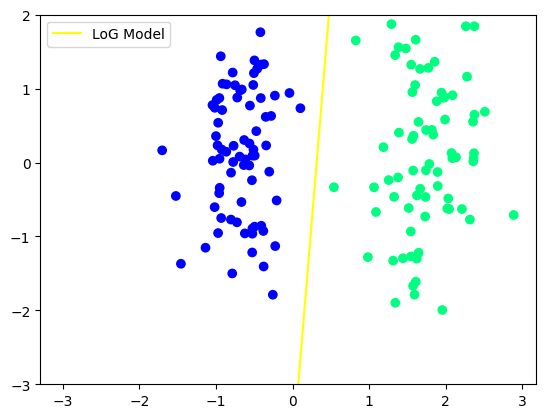

In [11]:
plt.scatter(X[:,0],X[:,1], c= y, cmap= 'winter')
plt.plot(x_input,y_input, color = 'yellow',label = "LoG Model")
plt.legend()
plt.ylim(-3,2)

# Our Model 

In [17]:
def gradient_descent(X,y,epochs,lr): 

    X = np.insert(X,1,0,axis = 1) 
    weights = np.ones(X.shape[1])
    
    for i in range(epochs): 
        y_hat = sigmoid(np.dot(X,weights)) 
        weights = weights - (lr*np.dot((y-y_hat),X))/X.shape[0]
        return weights[1:],weights[0]

In [18]:
def sigmoid(z): 
    return 1/(1+ np.exp(-z))

In [23]:
coef_,intercept_ = gradient_descent(X,y,2500,0.01)

In [24]:
coef_

array([1.        , 1.00174974])

In [25]:
intercept_

0.9973528388147082

In [26]:
m_new = -(coef_[0]/coef_[1]) 
b_new = -(intercept_/coef_[1])
m_new,b_new

(-0.9982533193059335, -0.9956107818659782)

In [27]:
input_x = np.linspace(-3,2,150) 
input_y = m*input_x + b

(-3.0, 2.0)

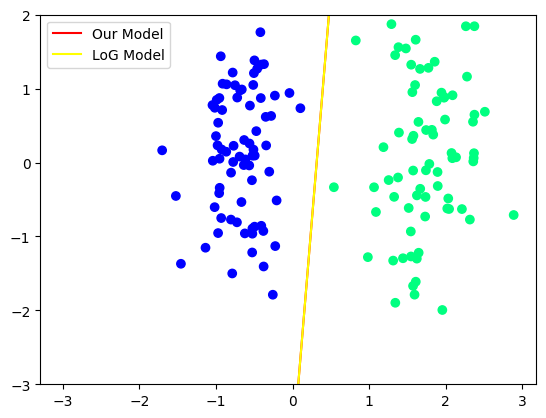

In [30]:
plt.scatter(X[:,0],X[:,1], c= y, cmap= 'winter')
plt.plot(input_x,input_y, color = 'red',label = "Our Model")
plt.plot(x_input,y_input, color = 'yellow',label = "LoG Model")
plt.legend()
plt.ylim(-3,2)

# Done